## Reaction time analysis

In [104]:
import numpy as np
import pandas as pd
from glob import glob
from matplotlib import pyplot as plt
import seaborn as sns
import pickle as pkl
import manifold.reaction_time as mrx

In [105]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# trial_files = np.sort(glob("../data/processed/glm-hmm-output/individual_sessions/*/*.pqt"))

In [114]:
with open("../data/processed/glm-hmm-output/glm_ouptut_all_animals.pkl", "rb") as f:
    trial_files = pkl.load(f)

In [115]:
with open("../data/processed/glm-hmm-output/action_kernel_trials.pkl", "rb") as f:
    action_kernel_files = pkl.load(f)

336

In [118]:
all_animals_df = []

for eid in trial_files.keys():
    _, _, df_all = mrx.load_trials_and_plot(trial_files, action_kernel_files, eid)
    # eid = trial_files[idx].rsplit("/")[-2]
    df_all["animal_id"] = eid
    all_animals_df.append(df_all)

In [69]:
cohort_df = pd.concat(all_animals_df)

In [31]:
cohort_df = cohort_df.reset_index()

In [70]:
cohort_df_correct = cohort_df[cohort_df["feedbackType"] == 1.0].copy()
cohort_df_incorrect = cohort_df[cohort_df["feedbackType"] == -1.0].copy()

cohort_rt_overall = (
    cohort_df_correct.groupby(["animal_id", "contrast_ordinal", "Prior_Label"])["rt_sec"]
    .median()
    .reset_index()
)

cohort_counts_overall = (
    cohort_df_correct.groupby(["contrast_ordinal", "Prior_Label"])
    .size()
    .reset_index(name="n_trials")
)

cohort_rt_correct_state = (
    cohort_df_correct.groupby(
        ["animal_id", "contrast_ordinal", "Prior_Label", "engagement_state"]
    )["rt_sec"]
    .median()
    .reset_index()
)

cohort_counts_correct_state = (
    cohort_df_correct.groupby(["contrast_ordinal", "Prior_Label", "engagement_state"])
    .size()
    .reset_index(name="n_trials")
)

cohort_rt_incorrect_state = (
    cohort_df_incorrect.groupby(
        ["animal_id", "contrast_ordinal", "Prior_Label", "engagement_state"]
    )["rt_sec"]
    .median()
    .reset_index()
)

cohort_counts_incorrect_state = (
    cohort_df_incorrect.groupby(["contrast_ordinal", "Prior_Label", "engagement_state"])
    .size()
    .reset_index(name="n_trials")
)

ylim = (0.1, 0.8)

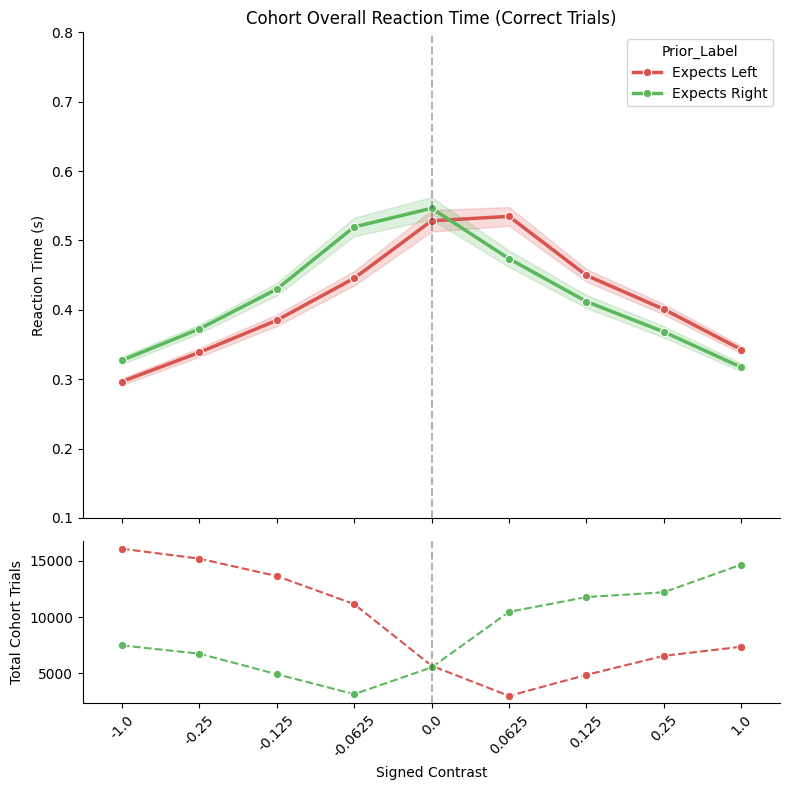

In [71]:
mrx.plot_cohort_overall_rt(cohort_rt_overall, cohort_counts_overall, ylim)

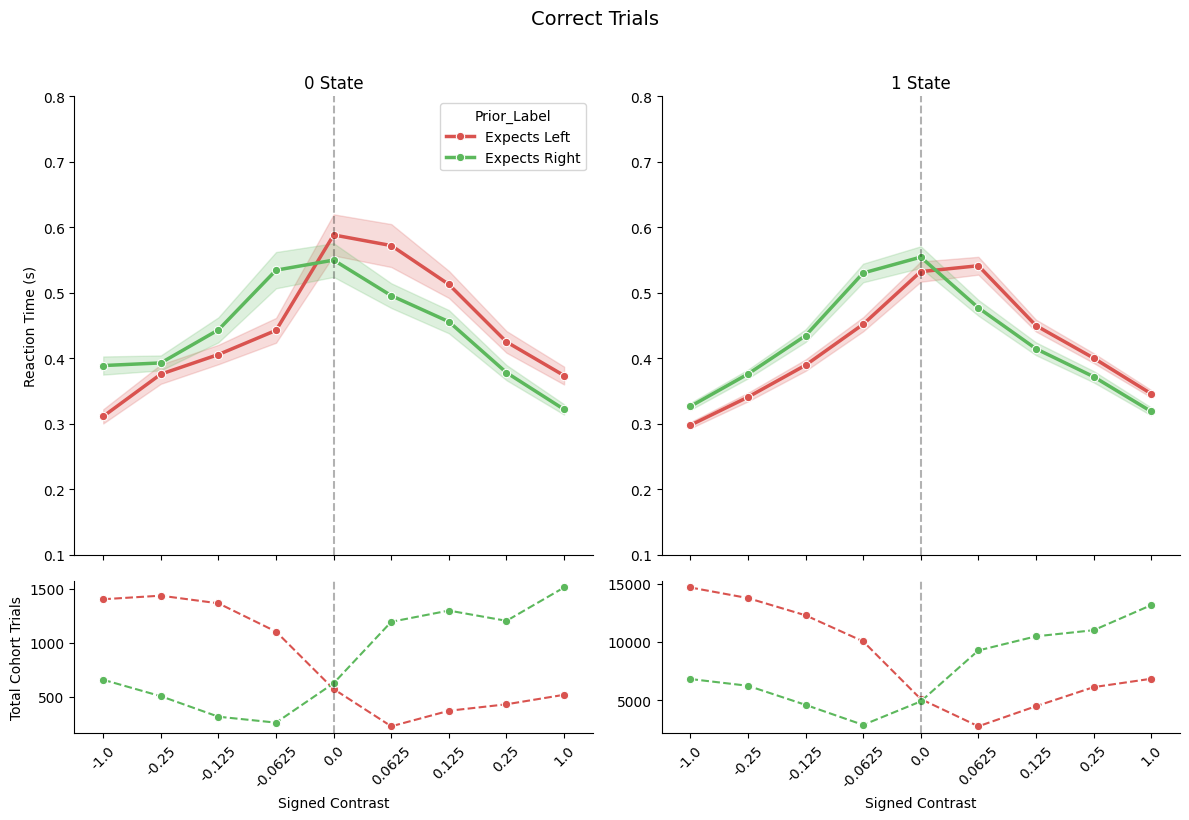

In [72]:
mrx.plot_cohort_rt_by_engagement(
    cohort_rt_correct_state,
    cohort_counts_correct_state,
    title="Correct Trials",
    ylim=ylim,
    state_idx="engagement_state",
)

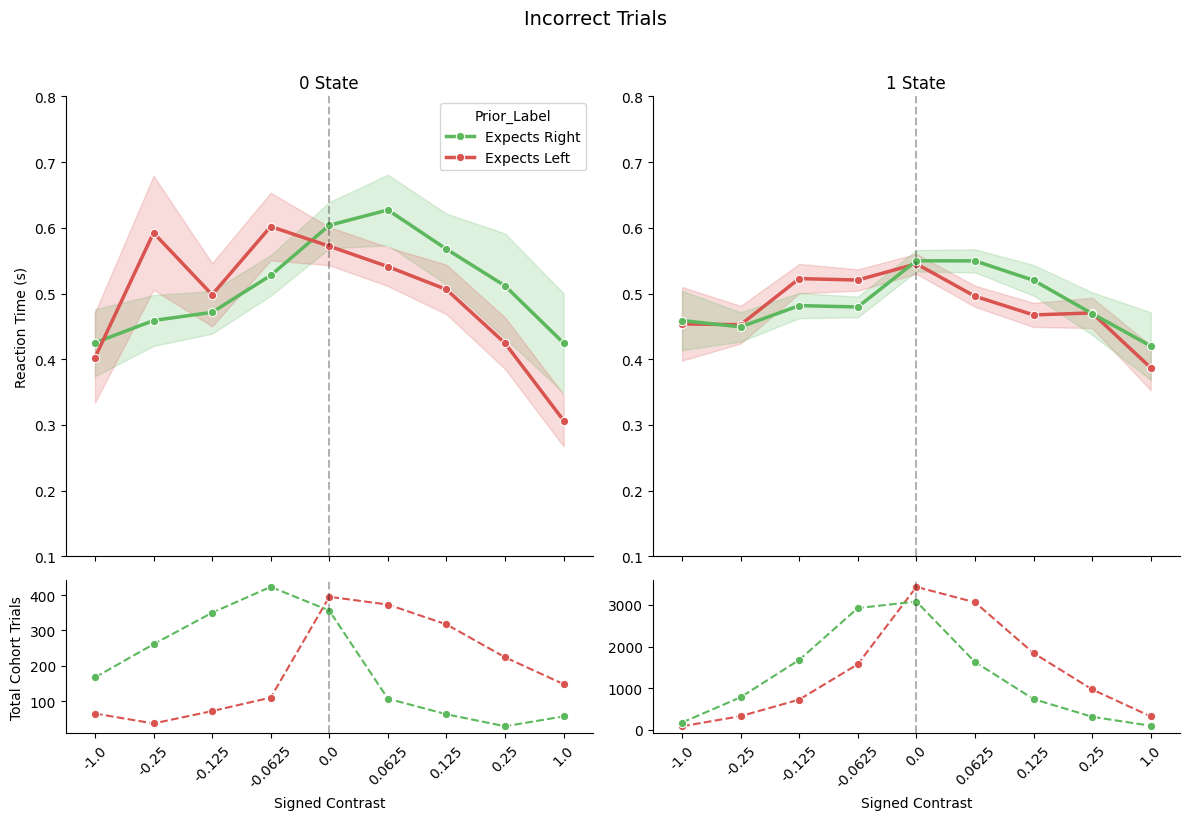

In [73]:
mrx.plot_cohort_rt_by_engagement(
    cohort_rt_incorrect_state,
    cohort_counts_incorrect_state,
    title="Incorrect Trials",
    drop_errors=False,
    ylim=ylim,
    state_idx="engagement_state",
)

In [ ]:
results = mrx.run_all_behavioral_lmms(df_cohort=cohort_df, state_column="hmm_state_label")

In [75]:
cleaned = mrx.clean_lmm_results(results)

In [76]:
cleaned

,Model,Effect (ms),StdErr (ms),z-score,p-value,Sig.
Intercept,Main Effects,496.3,5.9,83.56,0.0000,***
Incongruent,Main Effects,44.6,1.5,29.00,0.0000,***
disengaged,Main Effects,-19.5,2.5,-7.89,0.0000,***
Contrast (0 to 1),Main Effects,-162.9,1.8,-92.83,0.0000,***
Intercept,2 Way Interaction,496.7,5.9,83.60,0.0000,***
Incongruent,2 Way Interaction,43.5,1.6,27.13,0.0000,***
disengaged,2 Way Interaction,-22.8,2.8,-8.16,0.0000,***
Incongruent x disengaged,2 Way Interaction,14.4,5.7,2.54,0.0110,*
Contrast (0 to 1),2 Way Interaction,-163.0,1.8,-92.86,0.0000,***
Intercept,3 Way Interaction,498.1,6.2,79.70,0.0000,***


- $RT_{ij}$​ is the reaction time for animal i on trial j.
- $b_{0i}$​ is the Random Effect (the unique baseline speed offset for animal i).
- $ϵ_{ij}$​ is the Residual Error (the remaining trial-to-trial noise).
- $Contrast_{ij}$​ is the continuous visual contrast (from 0 to 1).
- $Incongruent_{ij}$​, $Disengaged_{ij}$​, and $Incorrect_{ij}$​ are Binary Indicator Variables 
- (they equal 1 if the condition is true, and 0 if it is false). 
- the default state (where all these equal 0) is a Congruent, Engaged, Correct trial.
---

- Model 1: The Main Effects Model (Correct Trials Only)
- Purpose: To establish the baseline cost of cognitive conflict and disengagement, assuming they act completely independently of each other.
- $RT_{ij}​=β0​+β1​(Incongruent_{ij}​)+β2​(Disengaged_{ij}​)+β3​(Contrast_{ij}​)+b_{0i}​+ϵ_{ij}​$

---

- Model 2: The 2-Way Interaction Model (Correct Trials Only)

- Purpose: To test if the animal's internal state (Engagement) fundamentally changes how it processes cognitive conflict.
- $RT_{ij}​=β0​+β1​(Incongruent_{ij}​)+β2​(Disengaged_{ij}​)+β3​(Incongruent_{ij}​×Disengaged_{ij}​)+β4​(Contrast_{ij}​)+b_{0i}​+ϵ_{ij}​$
---

- Model 3: The 3-Way Interaction Model (All Trials)

- Purpose: To model the complete behavioral architecture, specifically hunting for the "Prior Capture" signature by bringing error trials into the equation.
- $RT_{ij}​=β0​+β1​(Incongruent_{ij}​)+β2​(Disengaged_{ij}​)+β3​(Incorrect_{ij}​)+β4​(Incongruent_{ij}​×Disengaged_{ij}​)+β5​(Incongruent_{ij}​×Incorrect_{ij}​)+β6​(Disengaged_{ij}​×Incorrect_{ij}​)+β7​(Incongruent_{ij}​×Disengaged_{ij}​×Incorrect_{ij}​)+β8​(Contrast_{ij}​)+b_{0i}​+ϵ_{ij}​$


In [77]:
from manifold.engagement_manifolds import action_kernel_and_hmm_state

In [100]:
masks, conditions = action_kernel_and_hmm_state(
    "ss", 0, congruent_split=True, include_history=False
)

In [ ]:
# recreate a similar pickle as for action prior

In [107]:
all_trials_pickle = {}

In [112]:
for files in trial_files:
    df = pd.read_parquet(files)
    eid = files.rsplit("/")[-2]
    all_trials_pickle[eid] = df

In [113]:
with open("../data/processed/glm-hmm-output/glm_ouptut_all_animals.pkl", "wb") as f:
    pkl.dump(all_trials_pickle, f)